# Import Library

In [2]:
# 1. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pycaret.regression import *

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Loadd Data

In [3]:
data = pd.read_csv(r"D:\Sem 4\MLOps\Mg_6\pemodelan sementara\data\clean_data.csv")
data.head()

,order_id,order_status,customer,order_date,order_quantity,sales,discount,discount_value,product_category,product_sub_category
0,3,Order Finished,Muhammed Mac Intyre,2010-10-13,6,523080,0.04,20923,Office Supplies,Storage & Organization
1,293,Order Finished,Barry French,2012-10-01,49,20246040,0.07,1417223,Office Supplies,Appliances
2,483,Order Finished,Clay Rozendal,2011-07-10,30,9931519,0.08,794522,Technology,Telephones & Communication
3,515,Order Finished,Carlos Soltero,2010-08-28,19,788540,0.08,63083,Office Supplies,Appliances
4,613,Order Finished,Carl Jackson,2011-06-17,12,187080,0.03,5612,Office Supplies,Binders & Binder Accessories


# Cek Missing 

In [4]:
misdata = data.isnull().sum()
print(misdata)

order_id                0
order_status            0
customer                0
order_date              0
order_quantity          0
sales                   0
discount                0
discount_value          0
product_category        0
product_sub_category    0
dtype: int64


# produk 
##### LUREHOLIC Rak Holder Joran Pancing Wall Mount Fishing Rod 6 Slot - R5 / Rak Pancing Dinding


In [5]:
produk = data[data["product_sub_category"] == "Appliances"]

In [6]:

# =========================================================
# 5. CONVERT DATE
# =========================================================

produk["order_date"] = pd.to_datetime(
    produk["order_date"]
)


# target forecasting

In [7]:
# =========================================================
# 6. WEEKLY AGGREGATION
# =========================================================

produk = produk.sort_values(by='order_date')

weekly = (
    produk.groupby(pd.Grouper(key='order_date', freq='W'))['order_quantity']
    .sum()
    .reset_index()
)

In [8]:
print(weekly.describe())

                order_date  order_quantity
count                  208      208.000000
mean   2011-01-05 12:00:00       44.750000
min    2009-01-11 00:00:00        0.000000
25%    2010-01-08 06:00:00       14.000000
50%    2011-01-05 12:00:00       38.500000
75%    2012-01-02 18:00:00       66.000000
max    2012-12-30 00:00:00      166.000000
std                    NaN       37.861877


# visualisasi Time series

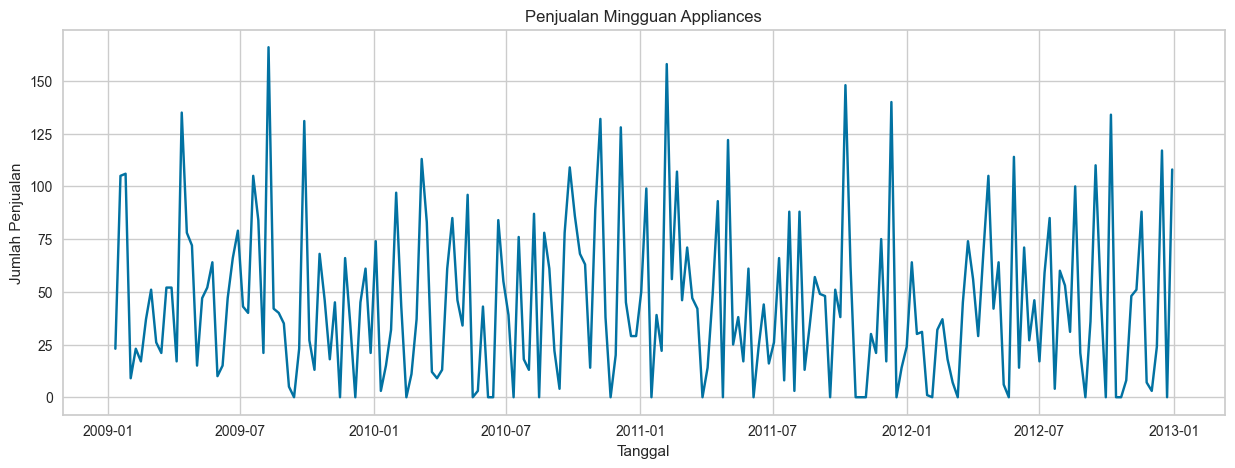

In [9]:
# 7. VISUALISASI
# =========================================================

plt.figure(figsize=(15,5))

plt.plot(
    weekly["order_date"],
    weekly["order_quantity"]
)

plt.title("Penjualan Mingguan Appliances")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Penjualan")

plt.show()

In [10]:
print(len(weekly))


208


# Feature Engineer


In [11]:
# =========================================================
# 8. FEATURE ENGINEERING
# =========================================================

# -------------------------
# LAG FEATURE
# -------------------------

weekly["lag_1"] = (
    weekly["order_quantity"].shift(1)
)

weekly["lag_2"] = (
    weekly["order_quantity"].shift(2)
)

weekly["lag_3"] = (
    weekly["order_quantity"].shift(3)
)


In [12]:
# -------------------------
# ROLLING MEAN
# -------------------------

weekly["rolling_mean_3"] = (
    weekly["order_quantity"]
    .rolling(3)
    .mean()
)

weekly["rolling_mean_6"] = (
    weekly["order_quantity"]
    .rolling(6)
    .mean()
)

In [13]:
# -------------------------
# ROLLING STD
# -------------------------

weekly["rolling_std_3"] = (
    weekly["order_quantity"]
    .rolling(3)
    .std()
)

weekly["rolling_std_6"] = (
    weekly["order_quantity"]
    .rolling(6)
    .std()
)

In [14]:
# # -------------------------
# # GROWTH RATE
# # -------------------------

# weekly["growth_rate"] = (
#     weekly["order_quantity"]
#     .pct_change()
# )

In [15]:
# =========================================================
# 9. HAPUS NULL
# =========================================================

weekly = weekly.dropna()

In [16]:
# =========================================================
# 10. CEK DATA
# =========================================================

print(weekly.head())

print(weekly.shape)


  order_date  order_quantity  lag_1  lag_2  lag_3  rolling_mean_3  \
5 2009-02-15              17   23.0    9.0  106.0       16.333333   
6 2009-02-22              37   17.0   23.0    9.0       25.666667   
7 2009-03-01              51   37.0   17.0   23.0       35.000000   
8 2009-03-08              26   51.0   37.0   17.0       38.000000   
9 2009-03-15              21   26.0   51.0   37.0       32.666667   

   rolling_mean_6  rolling_std_3  rolling_std_6  
5       47.166667       7.023769      45.477100  
6       49.500000      10.263203      44.333960  
7       40.500000      17.088007      35.393502  
8       27.166667      12.529964      14.945456  
9       29.166667      16.072751      12.655697  
(203, 9)


# Split Train Test

In [17]:
# =========================================================
# 11. TRAIN TEST SPLIT
# =========================================================

train_size = int(
    len(weekly) * 0.8
)

train = weekly.iloc[:train_size]

test = weekly.iloc[train_size:]

print("Train:", train.shape)
print("Test :", test.shape)

Train: (162, 9)
Test : (41, 9)


In [18]:
print(len(train))
print(len(test))

162
41


# Setup PyCaret

In [19]:
# =========================================================
# 12. SETUP PYCARET REGRESSION
# =========================================================

reg_setup = setup(
    data=train,
    target="order_quantity",
    session_id=123,
    fold=3,
    normalize=True,
    experiment_name="weekly_sales_forecasting",
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,order_quantity
2,Target type,Regression
3,Original data shape,"(162, 9)"
4,Transformed data shape,"(162, 11)"
5,Transformed train set shape,"(113, 11)"
6,Transformed test set shape,"(49, 11)"
7,Numeric features,7
8,Date features,1
9,Preprocess,True


# Compare model

In [20]:
# =========================================================
# 13. COMPARE MODEL
# =========================================================

best_model = compare_models()
print(best_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,2.4533
lar,Least Angle Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0300
br,Bayesian Ridge,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0333
par,Passive Aggressive Regressor,0.0517,0.0042,0.0649,1.0000,0.0270,0.0025,0.0333
huber,Huber Regressor,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0400
ridge,Ridge Regression,2.5462,10.0851,3.1577,0.9908,0.5730,0.1066,0.0333
lasso,Lasso Regression,3.4769,19.5682,4.2143,0.9866,0.6907,0.1871,1.7100
llar,Lasso Least Angle Regression,3.4727,19.5252,4.2092,0.9866,0.6903,0.1869,0.0300
gbr,Gradient Boosting Regressor,16.8154,524.7273,22.9054,0.4731,1.3042,0.8452,0.0667
catboost,CatBoost Regressor,20.0340,726.1554,26.5208,0.4137,1.4007,0.9797,1.0533


LinearRegression(n_jobs=-1)


# Tuning Model

In [21]:
# =========================================================
# 14. TUNING MODEL
# =========================================================

tuned_model = tune_model(
    best_model
)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
Mean,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
Std,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


# Evaluasi

In [22]:
# =========================================================
# 15. EVALUATE MODEL
# =========================================================

evaluate_model(
    tuned_model
)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Prediksi

In [23]:
# =========================================================
# 16. PREDICT TEST DATA
# =========================================================

pred_test = predict_model(
    tuned_model,
    data=test
)

print(pred_test.head())

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000


    order_date  lag_1  lag_2  lag_3  rolling_mean_3  rolling_mean_6  \
167 2012-03-25   45.0    0.0    7.0       39.666668       30.166666   
168 2012-04-01   74.0   45.0    0.0       58.333332       33.333332   
169 2012-04-08   56.0   74.0   45.0       53.000000       35.166668   
170 2012-04-15   29.0   56.0   74.0       51.000000       45.333332   
171 2012-04-22   68.0   29.0   56.0       67.333336       62.833332   

     rolling_std_3  rolling_std_6  order_quantity  prediction_label  
167      37.287174      27.505756              74         74.000005  
168      14.640127      29.473152              56         55.999998  
169      22.649504      28.659494              29         29.000001  
170      19.974985      27.463915              68         68.000001  
171      38.004387      26.225306             105        105.000008  


In [24]:
# =========================================================
# 17. HITUNG METRIC
# =========================================================

mae = mean_absolute_error(
    test["order_quantity"],
    pred_test["prediction_label"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["order_quantity"],
        pred_test["prediction_label"]
    )
)

r2 = r2_score(
    test["order_quantity"],
    pred_test["prediction_label"]
)

print("\n===== EVALUATION =====")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


===== EVALUATION =====
MAE : 2.979075429270391e-06
RMSE: 3.733199552306375e-06
R2  : 0.9999999999999909


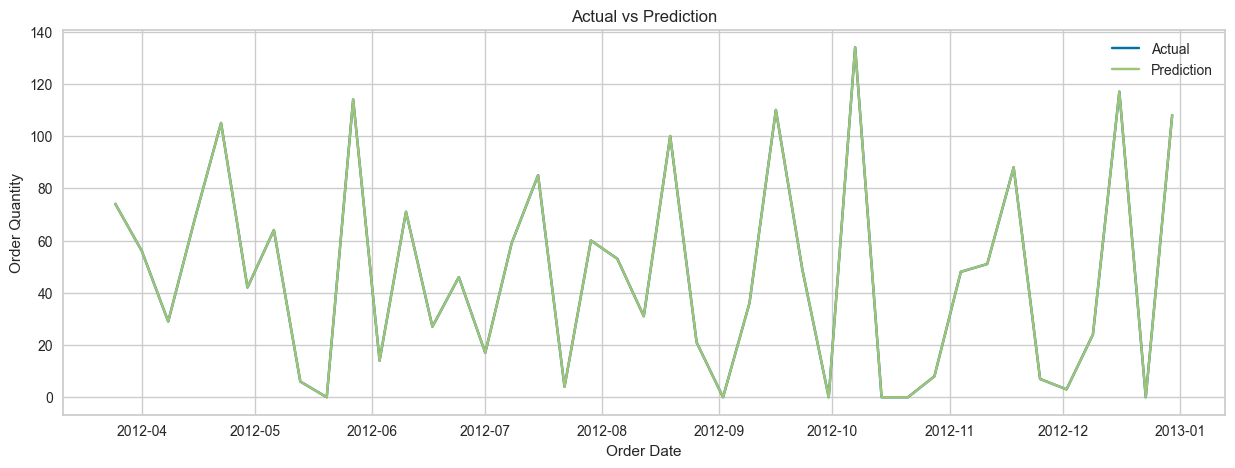

In [25]:
# =========================================================
# 18. VISUALISASI HASIL PREDIKSI
# =========================================================

plt.figure(figsize=(15,5))

plt.plot(
    test["order_date"],
    test["order_quantity"],
    label="Actual"
)

plt.plot(
    test["order_date"],
    pred_test["prediction_label"],
    label="Prediction"
)

plt.title("Actual vs Prediction")

plt.xlabel("Order Date")
plt.ylabel("Order Quantity")

plt.legend()

plt.show()

In [26]:
# =========================================================
# 19. FINALIZE MODEL
# =========================================================

final_model = finalize_model(
    tuned_model
)

# Save Model

In [27]:

# =========================================================
# 20. SAVE MODEL
# =========================================================

save_model(
    final_model,
    "best_model_weekly_sales-appliances"
)

print("\nModel berhasil disimpan!")

Transformation Pipeline and Model Successfully Saved

Model berhasil disimpan!
